<a href="https://colab.research.google.com/github/farukkilinc1903/group6-innovation-campus-samsung/blob/main/Assignment3_Part_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 3**

# **PART A: Model Refinement**

## **1. Overview**

This section focuses on the model refinement phase of the project. In the previous stage, different regression models were compared to predict school electricity access using country-level socio-economic, infrastructure, and satellite-based indicators. The target variable is Electricity_Access_Percent.

After comparing Random Forest, XGBoost, and Gradient Boosting, XGBoost achieved the best overall performance and was selected for refinement. In this phase, GroupShuffleSplit is used for train-test splitting and GroupKFold is used for cross-validation to prevent data leakage across country-year observations.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold,
    cross_val_score, GridSearchCV
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Load datasets
school_df = pd.read_csv("d0.school_electricity_access.csv")
national_electricity_df = pd.read_csv("d1.TOT.ELCT.ACCS.csv", skiprows=4)
gdp_df = pd.read_csv("d2.GDP.DATA.csv", skiprows=4)
education_df = pd.read_csv("d3.EDU.EXP.csv", skiprows=4)
urban_df = pd.read_csv("d4.URBAN.POP.csv", skiprows=4)
nasa_df = pd.read_excel("d5.NASA.UYDU.xlsx", sheet_name="Data")

print("Datasets loaded successfully.")


Datasets loaded successfully.


In [2]:
# World Bank Data Preparation
def format_world_bank_data(df, value_name):
    years = [str(year) for year in range(1992, 2014)]
    df_long = df.melt(
        id_vars=["Country Code"],
        value_vars=years,
        var_name="Year",
        value_name=value_name
    )
    df_long["Year"] = df_long["Year"].astype(int)
    df_long = df_long.rename(columns={"Country Code": "ISO"})
    return df_long

national_electricity_long = format_world_bank_data(national_electricity_df, "National_Electricity_Access")
gdp_long = format_world_bank_data(gdp_df, "GDP_per_Capita")
education_long = format_world_bank_data(education_df, "Education_Expenditure")
urban_long = format_world_bank_data(urban_df, "Urban_Population")

print("World Bank datasets converted successfully.")


World Bank datasets converted successfully.


In [3]:
# NASA and School Data Preparation
school_df = school_df.rename(columns={"ISO_Code": "ISO"})

nasa_selected = nasa_df[["ISO", "Year", "stbSoL", "Lpc", "Pdens", "wGini_L050"]]
school_selected = school_df[["ISO", "Year", "Electricity_Access_Percent"]]


In [4]:
# Merge Datasets
merged_df = school_selected.copy()
for df in [nasa_selected, national_electricity_long, gdp_long, education_long, urban_long]:
    merged_df = pd.merge(merged_df, df, on=["ISO", "Year"], how="inner")

merged_df = merged_df.dropna()

print("Final dataset shape:", merged_df.shape)
merged_df.head()


Final dataset shape: (223, 11)


,ISO,Year,Electricity_Access_Percent,stbSoL,Lpc,Pdens,wGini_L050,National_Electricity_Access,GDP_per_Capita,Education_Expenditure,Urban_Population
1,ARG,2009,92.342361,2.854422e+06,0.071943,14.251959,0.629623,97.8,8150.235270,16.020670,90.820902
2,ABW,2010,100.000000,7.212818e+03,0.071073,448.464824,0.551859,93.4,24093.140151,22.176781,64.161297
18,BGD,2012,55.384041,4.007569e+05,0.002742,1024.967497,0.736576,65.5,859.680536,15.745120,28.478797
19,BRB,2009,100.000000,1.599105e+04,0.057769,564.269337,0.478147,100.0,16294.909949,16.100580,59.294492
22,BEL,2005,100.000000,1.401670e+06,0.133186,342.414704,0.525086,100.0,36809.701340,11.175520,83.564545


In [5]:
# Define Features and Target
X = merged_df.drop(columns=["ISO", "Year", "Electricity_Access_Percent"])
y = merged_df["Electricity_Access_Percent"]
groups = merged_df["ISO"]

print("Features:", X.columns.tolist())
print("Target:", y.name)
print("Number of countries:", groups.nunique())


Features: ['stbSoL', 'Lpc', 'Pdens', 'wGini_L050', 'National_Electricity_Access', 'GDP_per_Capita', 'Education_Expenditure', 'Urban_Population']
Target: Electricity_Access_Percent
Number of countries: 53


In [6]:
# Train-Test Split (Group-based to prevent data leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Train countries: {groups_train.nunique()} | Test countries: {groups.iloc[test_idx].nunique()}")


Train size: 173 | Test size: 50
Train countries: 42 | Test countries: 11


## **2. Model Evaluation**

### Initial XGBoost Model

In [7]:
# Initial XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)

xgb_r2   = r2_score(y_test, xgb_predictions)
xgb_mae  = mean_absolute_error(y_test, xgb_predictions)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

print("Initial XGBoost Results")
print(f"R2 Score : {xgb_r2:.4f}")
print(f"MAE      : {xgb_mae:.4f}")
print(f"RMSE     : {xgb_rmse:.4f}")


Initial XGBoost Results
R2 Score : 0.9209
MAE      : 1.6716
RMSE     : 5.8279


In [8]:
# Cross-Validation for Initial XGBoost (GroupKFold)
gkfold = GroupKFold(n_splits=3)

xgb_cv_scores = cross_val_score(
    xgb_model, X_train, y_train,
    cv=gkfold, groups=groups_train, scoring="r2"
)

print("Initial XGBoost Cross-Validation Scores:", xgb_cv_scores)
print(f"Mean CV R2 : {xgb_cv_scores.mean():.4f}")
print(f"Std Dev    : {xgb_cv_scores.std():.4f}")


Initial XGBoost Cross-Validation Scores: [0.4599504  0.73701697 0.9054532 ]
Mean CV R2 : 0.7008
Std Dev    : 0.1837


## **3. Refinement Techniques**

Three refinement techniques were applied: hyperparameter tuning with GridSearchCV, cross-validation with GroupKFold to prevent data leakage, and feature importance-based feature selection.

## **4. Hyperparameter Tuning**

In [9]:
# Hyperparameter Tuning with GridSearchCV
param_grid = {
    "n_estimators"     : [100, 200, 300],
    "learning_rate"    : [0.01, 0.05, 0.1],
    "max_depth"        : [3, 4, 5],
    "subsample"        : [0.8, 1.0],
    "colsample_bytree" : [0.8, 1.0]
}

xgb_base = XGBRegressor(random_state=42, objective="reg:squarederror")

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=gkfold,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train, groups=groups_train)

print("Best Parameters:")
print(grid_search.best_params_)
print(f"Best CV R2: {grid_search.best_score_:.4f}")


Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Best CV R2: 0.8089


In [10]:
# Tuned XGBoost Evaluation
tuned_xgb_model = grid_search.best_estimator_
tuned_predictions = tuned_xgb_model.predict(X_test)

tuned_r2   = r2_score(y_test, tuned_predictions)
tuned_mae  = mean_absolute_error(y_test, tuned_predictions)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))

# Cross-Validation for Tuned Model
tuned_cv_scores = cross_val_score(
    tuned_xgb_model, X_train, y_train,
    cv=gkfold, groups=groups_train, scoring="r2"
)

print("Tuned XGBoost Results")
print(f"R2 Score   : {tuned_r2:.4f}")
print(f"MAE        : {tuned_mae:.4f}")
print(f"RMSE       : {tuned_rmse:.4f}")
print(f"Mean CV R2 : {tuned_cv_scores.mean():.4f}")
print(f"Std Dev    : {tuned_cv_scores.std():.4f}")


Tuned XGBoost Results
R2 Score   : 0.9245
MAE        : 2.0712
RMSE       : 5.6924
Mean CV R2 : 0.8089
Std Dev    : 0.1114


In [11]:
# Compare Initial vs Tuned XGBoost
xgb_refinement_results = pd.DataFrame({
    "Model"      : ["Initial XGBoost", "Tuned XGBoost"],
    "R2 Score"   : [xgb_r2,   tuned_r2],
    "MAE"        : [xgb_mae,  tuned_mae],
    "RMSE"       : [xgb_rmse, tuned_rmse],
    "CV Mean R2" : [xgb_cv_scores.mean(), tuned_cv_scores.mean()],
    "CV Std"     : [xgb_cv_scores.std(),  tuned_cv_scores.std()]
})

xgb_refinement_results


,Model,R2 Score,MAE,RMSE,CV Mean R2,CV Std
0,Initial XGBoost,0.920897,1.671635,5.827917,0.700807,0.183669
1,Tuned XGBoost,0.924533,2.071228,5.692379,0.808916,0.111361


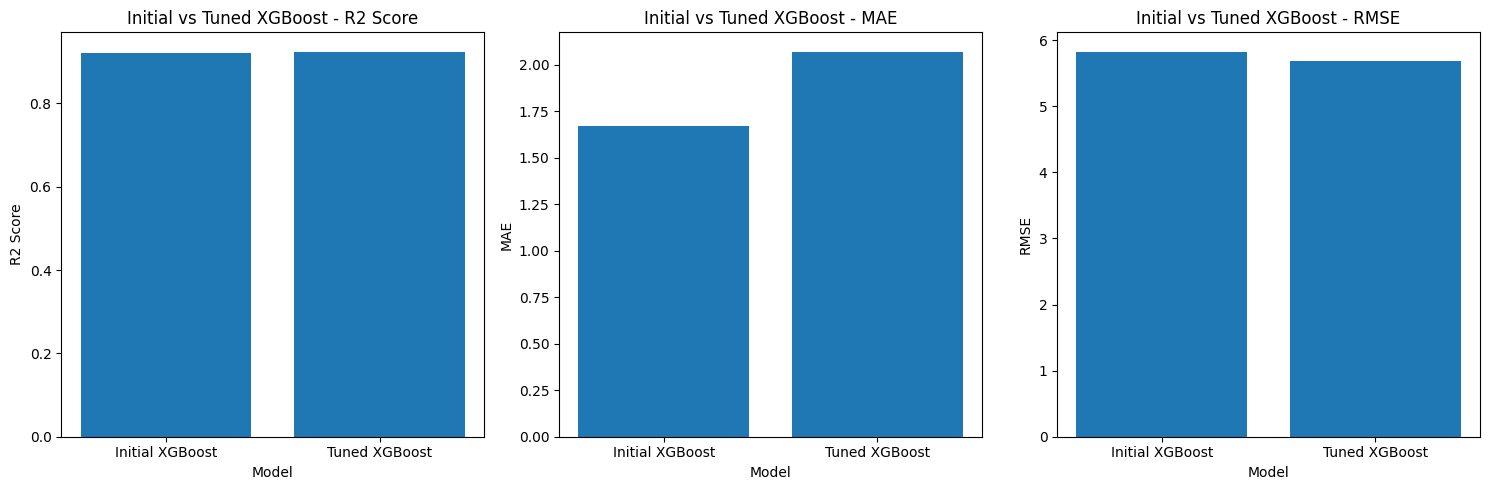

In [12]:
# Comparison Graphs
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ["R2 Score", "MAE", "RMSE"]

for ax, metric in zip(axes, metrics):
    ax.bar(xgb_refinement_results["Model"], xgb_refinement_results[metric])
    ax.set_title(f"Initial vs Tuned XGBoost - {metric}")
    ax.set_ylabel(metric)
    ax.set_xlabel("Model")

plt.tight_layout()
plt.show()


## **5. Cross-Validation**

In [13]:
# Select best model based on CV Mean R2 (more reliable than test R2 alone)
best_refinement_idx = xgb_refinement_results["CV Mean R2"].idxmax()
best_refinement_model_name = xgb_refinement_results.loc[best_refinement_idx, "Model"]

print("Best model after refinement (by CV Mean R2):", best_refinement_model_name)

if best_refinement_model_name == "Initial XGBoost":
    final_model      = xgb_model
    final_predictions = xgb_predictions
    final_cv_scores  = xgb_cv_scores
else:
    final_model      = tuned_xgb_model
    final_predictions = tuned_predictions
    final_cv_scores  = tuned_cv_scores


Best model after refinement (by CV Mean R2): Tuned XGBoost


## **6. Feature Selection**

                    Feature  Importance
             GDP_per_Capita    0.463985
National_Electricity_Access    0.192649
                        Lpc    0.163245
           Urban_Population    0.091612
                 wGini_L050    0.043099
                     stbSoL    0.020810
      Education_Expenditure    0.014788
                      Pdens    0.009813


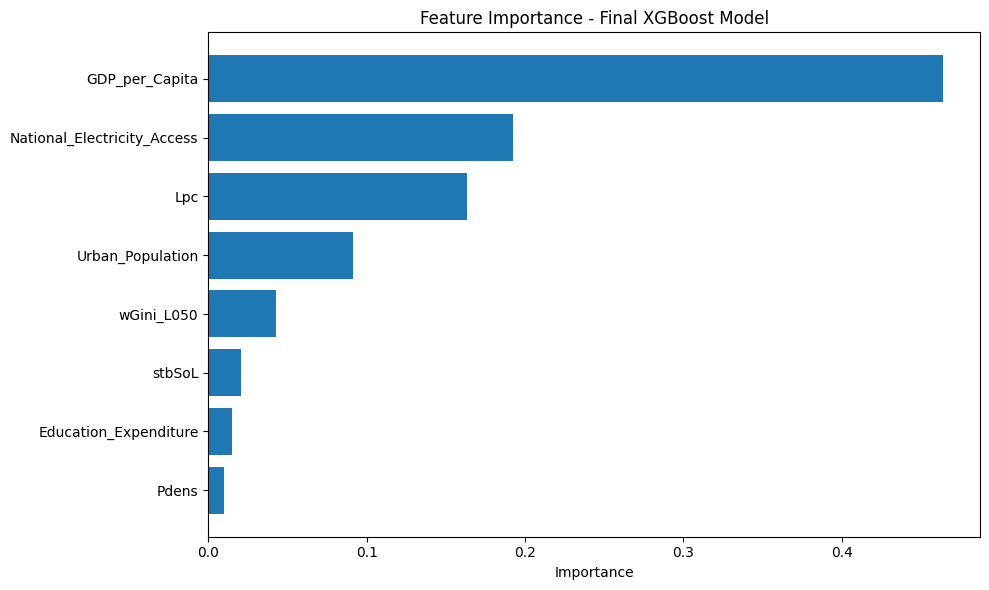

In [14]:
# Feature Importance of Final Model
feature_importance = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": final_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title(f"Feature Importance - Final XGBoost Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [15]:
# Feature Selection (above-mean importance)
importance_mean = feature_importance["Importance"].mean()
selected_features = feature_importance[
    feature_importance["Importance"] > importance_mean
]["Feature"].tolist()

print("Selected Features:", selected_features)


Selected Features: ['GDP_per_Capita', 'National_Electricity_Access', 'Lpc']


In [16]:
# Selected Feature XGBoost Model
X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

selected_xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

selected_xgb_model.fit(X_train_selected, y_train)
selected_predictions = selected_xgb_model.predict(X_test_selected)

selected_r2   = r2_score(y_test, selected_predictions)
selected_mae  = mean_absolute_error(y_test, selected_predictions)
selected_rmse = np.sqrt(mean_squared_error(y_test, selected_predictions))

# Cross-Validation for Selected Feature Model
selected_cv_scores = cross_val_score(
    selected_xgb_model, X_train_selected, y_train,
    cv=gkfold, groups=groups_train, scoring="r2"
)

print("Selected Feature XGBoost Results")
print(f"R2 Score   : {selected_r2:.4f}")
print(f"MAE        : {selected_mae:.4f}")
print(f"RMSE       : {selected_rmse:.4f}")
print(f"Mean CV R2 : {selected_cv_scores.mean():.4f}")
print(f"Std Dev    : {selected_cv_scores.std():.4f}")


Selected Feature XGBoost Results
R2 Score   : 0.8728
MAE        : 2.0929
RMSE       : 7.3891
Mean CV R2 : 0.7650
Std Dev    : 0.1598


In [17]:
# Final Part A Results Table (all 3 models + CV scores)
part_a_final_results = pd.DataFrame({
    "Model"      : ["Initial XGBoost", "Tuned XGBoost", "Selected Feature XGBoost"],
    "R2 Score"   : [xgb_r2,   tuned_r2,   selected_r2],
    "MAE"        : [xgb_mae,  tuned_mae,  selected_mae],
    "RMSE"       : [xgb_rmse, tuned_rmse, selected_rmse],
    "CV Mean R2" : [xgb_cv_scores.mean(), tuned_cv_scores.mean(), selected_cv_scores.mean()],
    "CV Std"     : [xgb_cv_scores.std(),  tuned_cv_scores.std(),  selected_cv_scores.std()]
})

part_a_final_results


,Model,R2 Score,MAE,RMSE,CV Mean R2,CV Std
0,Initial XGBoost,0.920897,1.671635,5.827917,0.700807,0.183669
1,Tuned XGBoost,0.924533,2.071228,5.692379,0.808916,0.111361
2,Selected Feature XGBoost,0.872840,2.092928,7.389108,0.765009,0.159797


In [18]:
# Final Model Selection (by CV Mean R2)
best_final_idx   = part_a_final_results["CV Mean R2"].idxmax()
best_final_model_name = part_a_final_results.loc[best_final_idx, "Model"]

print("Best final model:", best_final_model_name)

if best_final_model_name == "Initial XGBoost":
    final_model       = xgb_model
    final_predictions = xgb_predictions
    final_cv_scores   = xgb_cv_scores

elif best_final_model_name == "Tuned XGBoost":
    final_model       = tuned_xgb_model
    final_predictions = tuned_predictions
    final_cv_scores   = tuned_cv_scores

else:
    final_model       = selected_xgb_model
    final_predictions = selected_predictions
    final_cv_scores   = selected_cv_scores
    X_test            = X_test_selected


Best final model: Tuned XGBoost


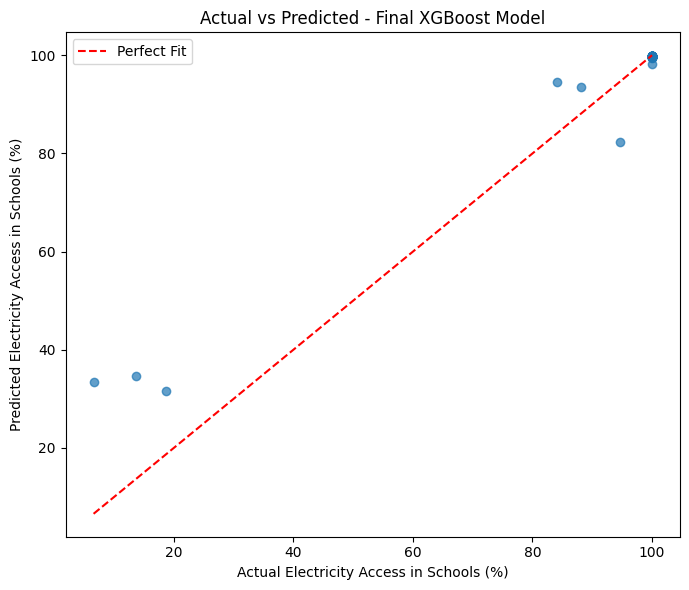

In [19]:
# Actual vs Predicted Plot
plt.figure(figsize=(7, 6))
plt.scatter(y_test, final_predictions, alpha=0.7)
min_val = min(y_test.min(), final_predictions.min())
max_val = max(y_test.max(), final_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Fit")
plt.xlabel("Actual Electricity Access in Schools (%)")
plt.ylabel("Predicted Electricity Access in Schools (%)")
plt.title("Actual vs Predicted - Final XGBoost Model")
plt.legend()
plt.tight_layout()
plt.show()


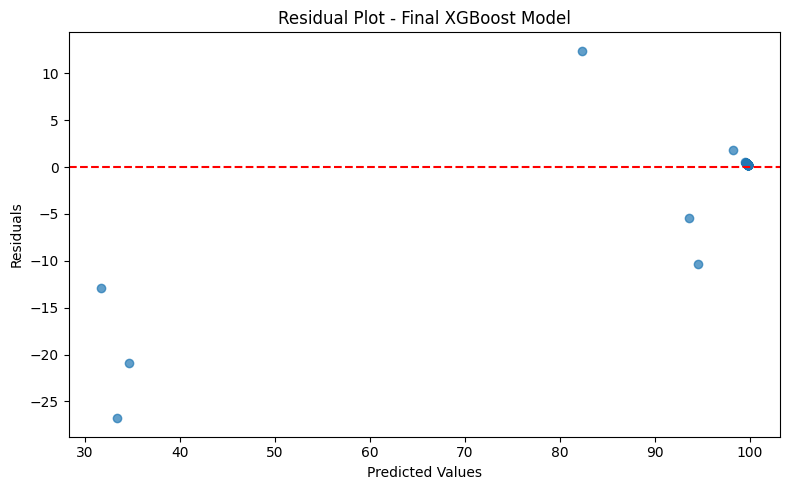

In [20]:
# Residual Plot
residuals = y_test - final_predictions

plt.figure(figsize=(8, 5))
plt.scatter(final_predictions, residuals, alpha=0.7)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Final XGBoost Model")
plt.tight_layout()
plt.show()


In [21]:
# Save Part A Results
xgb_refinement_results.to_csv("xgboost_refinement_results.csv", index=False)
feature_importance.to_csv("xgboost_feature_importance.csv", index=False)
part_a_final_results.to_csv("part_a_final_results.csv", index=False)

print("Part A results saved successfully.")
print("\nFinal Model Summary:")
final_row = part_a_final_results.loc[best_final_idx]
for col in part_a_final_results.columns:
    print(f"  {col}: {final_row[col]}")


Part A results saved successfully.

Final Model Summary:
  Model: Tuned XGBoost
  R2 Score: 0.9245333941521525
  MAE: 2.071228294372559
  RMSE: 5.692378741205293
  CV Mean R2: 0.808915900408309
  CV Std: 0.11136088559964587


## Part A Summary

In the model comparison stage (Assignment 2), three models were evaluated — Random Forest, XGBoost, and Gradient Boosting. XGBoost achieved the best overall performance and was selected for refinement in this phase.
The first key methodological improvement was the use of GroupShuffleSplit for train-test splitting and GroupKFold for cross-validation. Since the dataset consists of multiple years of observations per country, a standard random split would place the same country in both training and test sets, causing data leakage. By splitting on country groups, each country appears exclusively in either training or test, ensuring a fair and unbiased evaluation.
Three model variants were trained and compared. The Initial XGBoost used default parameters and achieved a test R² of 0.921 and a CV Mean R² of 0.701. Hyperparameter tuning was then applied using GridSearchCV, which tested 108 parameter combinations across n_estimators, learning_rate, max_depth, subsample, and colsample_bytree. The Tuned XGBoost (n_estimators=300, learning_rate=0.01, max_depth=3, subsample=0.8, colsample_bytree=0.8) improved the test R² to 0.925 and the CV Mean R² to 0.809, with a lower standard deviation of 0.111, indicating more stable generalization. Finally, feature selection was applied based on above-mean importance scores, yielding a three-feature model (GDP per capita, National Electricity Access, Lpc) with a test R² of 0.873 and CV Mean R² of 0.765.
**The Tuned XGBoost was selected as the final model for Part B and deployment**, as it achieved the highest CV Mean R² and the most consistent performance across folds.